# LES Intercomparison Study for CBL: Sensitivity with respect to Numerical Precision

*Last updated: May 2026*


For case setup and physical parameters, see the [Description](CBL_N91_Description.ipynb) notebook.

Precisions compared: double (DP), single (SP); SGS & grid: selected by the user.

## Setup

The next cells load Python packages, locate the simulation outputs, and define the grid and averaging window used throughout the notebook.


In [73]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directories


In [74]:
from pathlib import Path

# Base directory (JAXALFA0.1/)
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir = find_repo_root()

def read_config(run_dir):
    cfg = {}
    exec((run_dir / 'Config.py').read_text(), cfg)
    return cfg


optSGS = 1  # LASDD-SM: 1, LASDD-WL: 2, LAD-SM: 3, LAD-WL: 4
optRes = 3  # 64x64x64: 1, 128x128x128: 2, 256x256x256: 3, 384x384x384: 4

_res = {1: '64x64x64', 2: '128x128x128', 3: '256x256x256', 4: '384x384x384'}
_sgs = {1: 'LASDD_SM', 2: 'LASDD_WL', 3: 'LAD_SM', 4: 'LAD_WL'}

_sgs_label = {1: 'LASDD-SM', 2: 'LASDD-WL', 3: 'LAD-SM', 4: 'LAD-WL'}
_res_label = {1: r'$64^3$', 2: r'$128^3$', 3: r'$256^3$', 4: r'$384^3$'}

_run = f"{_res[optRes]}_{_sgs[optSGS]}"

OutputDir_DP = BaseDir / f'examples/CBL_N91/runs/{_run}_DP/output'
OutputDir_SP = BaseDir / f'examples/CBL_N91/runs/{_run}_SP/output'

### Case configuration


In [75]:
_cfg_ref = read_config(OutputDir_DP.parent if (OutputDir_DP.parent / 'Config.py').exists() else OutputDir_SP.parent)
nz = int(_cfg_ref['nz'])
l_z = float(_cfg_ref['l_z'])
z_damping = float(_cfg_ref.get('z_damping', np.nan))
OutputInterval_sec = float(_cfg_ref.get('OutputInterval_sec', 60.0))

# Averaging window — CBL quasi-steady state (hours 3.0-3.5)
T_start = 3.0 * 3600   # s
T_end   = 3.5 * 3600   # s

### Derived grid and averaging indices


In [76]:
# Half levels — u, v, TH
z_1 = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])

# Full levels — w, uw, vw, wTH, qz
z_w_1 = np.array([k * l_z / (nz - 1) for k in range(nz)])

# File indices for the averaging window
T_start_index = int(T_start / OutputInterval_sec) - 1
T_end_index   = int(T_end   / OutputInterval_sec) - 1

print(f'Averaging window: file indices {T_start_index} – {T_end_index}')

Averaging window: file indices 179 – 209


### Statistics loader


In [77]:
def LoadStatsAverage(stat_files, T_start_index, T_end_index, nz_expected):
    if len(stat_files) == 0:
        print(f'No statistics files available; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return tuple(nan.copy() for _ in range(15))

    U   = []; V   = []; TH  = []
    u2  = []; v2  = []; w2  = []; TH2 = []
    uv  = []; uw  = []; vw  = []
    txy = []; txz = []; tyz = []
    wTH = []; qz  = []

    for f in stat_files:
        with np.load(f) as d:
            U.append(d['U']);   V.append(d['V']);   TH.append(d['TH'])
            u2.append(d['u2']); v2.append(d['v2']); w2.append(d['w2'])
            TH2.append(d['TH2'])
            uv.append(d['uv']); uw.append(d['uw']); vw.append(d['vw'])
            txy.append(d['txy']); txz.append(d['txz']); tyz.append(d['tyz'])
            wTH.append(d['wTH']); qz.append(d['qz'])

    U  = np.array(U);  V  = np.array(V);  TH  = np.array(TH)
    u2 = np.array(u2); v2 = np.array(v2); w2  = np.array(w2); TH2 = np.array(TH2)
    uv = np.array(uv); uw = np.array(uw); vw  = np.array(vw)
    txy = np.array(txy); txz = np.array(txz); tyz = np.array(tyz)
    wTH = np.array(wTH); qz = np.array(qz)

    sl = slice(T_start_index, min(T_end_index + 1, len(stat_files)))
    if sl.start >= len(stat_files):
        print(f'Averaging window starts after available files; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return tuple(nan.copy() for _ in range(15))

    return (
        np.mean(U[sl],   axis=0), np.mean(V[sl],   axis=0), np.mean(TH[sl],  axis=0),
        np.mean(u2[sl],  axis=0), np.mean(v2[sl],  axis=0), np.mean(w2[sl],  axis=0),
        np.mean(TH2[sl], axis=0),
        np.mean(uv[sl],  axis=0), np.mean(uw[sl],  axis=0), np.mean(vw[sl],  axis=0),
        np.mean(txy[sl], axis=0), np.mean(txz[sl], axis=0), np.mean(tyz[sl], axis=0),
        np.mean(wTH[sl], axis=0), np.mean(qz[sl],  axis=0)
    )


### Available statistics files


In [78]:
def get_stat_files(output_dir):
    files = sorted(
        glob.glob(str(output_dir / 'ALFA_Statistics_Iteration_*.npz')),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files

StatFiles_DP = get_stat_files(OutputDir_DP)
StatFiles_SP = get_stat_files(OutputDir_SP)

### Temporally averaged profiles


In [79]:
(U_avg_DP, V_avg_DP, TH_avg_DP,
 u2_avg_DP, v2_avg_DP, w2_avg_DP, TH2_avg_DP,
 uv_avg_DP, uw_avg_DP, vw_avg_DP,
 txy_avg_DP, txz_avg_DP, tyz_avg_DP,
 wTH_avg_DP, qz_avg_DP) = LoadStatsAverage(StatFiles_DP, T_start_index, T_end_index, nz)

(U_avg_SP, V_avg_SP, TH_avg_SP,
 u2_avg_SP, v2_avg_SP, w2_avg_SP, TH2_avg_SP,
 uv_avg_SP, uw_avg_SP, vw_avg_SP,
 txy_avg_SP, txz_avg_SP, tyz_avg_SP,
 wTH_avg_SP, qz_avg_SP) = LoadStatsAverage(StatFiles_SP, T_start_index, T_end_index, nz)

M_avg_DP   = np.sqrt(U_avg_DP**2 + V_avg_DP**2)
uw_tot_DP  = uw_avg_DP  + txz_avg_DP
vw_tot_DP  = vw_avg_DP  + tyz_avg_DP
wTH_tot_DP = wTH_avg_DP + qz_avg_DP

M_avg_SP   = np.sqrt(U_avg_SP**2 + V_avg_SP**2)
uw_tot_SP  = uw_avg_SP  + txz_avg_SP
vw_tot_SP  = vw_avg_SP  + tyz_avg_SP
wTH_tot_SP = wTH_avg_SP + qz_avg_SP

print(f'Averaging over {T_end_index - T_start_index + 1} files '
      f'({T_start/3600:.1f}–{T_end/3600:.1f} h)')

Averaging over 31 files (3.0–3.5 h)


In [80]:
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

In [81]:
def plot_profile(x, z, xlabel, ylabel=r"$z$ (m)", linestyle='-k', label=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 6), constrained_layout=True)

    ax.plot(x, z, linestyle, linewidth=2, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)

## Mean Potential Temperature and Temperature Variance

The two panels compare the horizontally averaged potential-temperature profile and the resolved temperature variance over the 3.0-3.5 h averaging window.


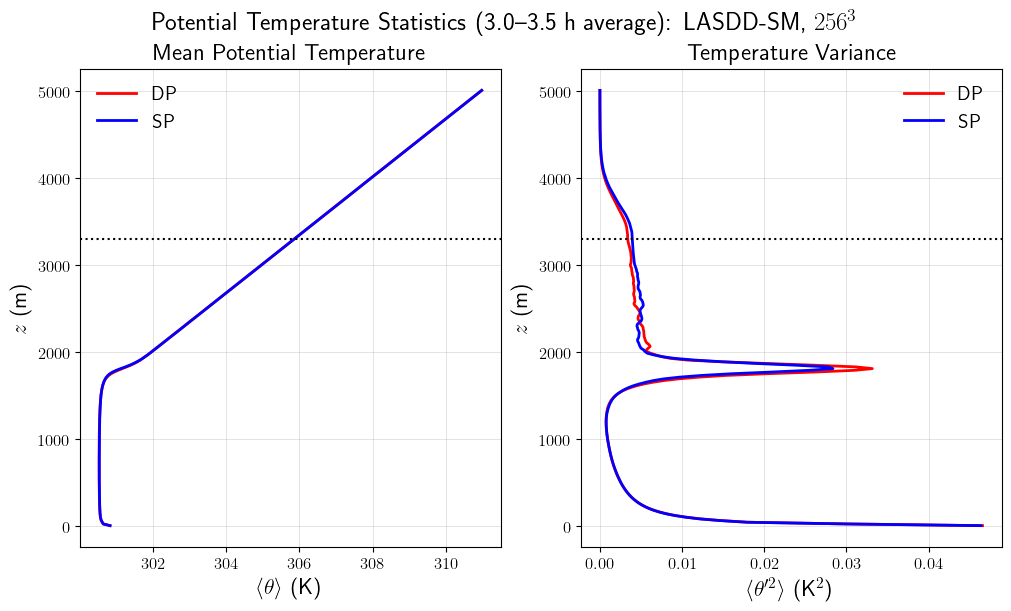

In [82]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

run_styles = {
    'DP': {'color': 'red',  'linestyle': '-'},
    'SP': {'color': 'blue', 'linestyle': '-'},
}

def plot_run_profile(ax, x, z, xlabel, run_label):
    style = run_styles[run_label]
    ax.plot(x, z, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=run_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$z$ (m)")

plot_run_profile(axs[0], TH_avg_DP, z_1, r"$\langle \theta \rangle$ (K)", 'DP')
plot_run_profile(axs[0], TH_avg_SP, z_1, r"$\langle \theta \rangle$ (K)", 'SP')
axs[0].set_title("Mean Potential Temperature")

plot_run_profile(axs[1], TH2_avg_DP, z_1, r"$\langle \theta^{\prime 2} \rangle$ (K$^2$)", 'DP')
plot_run_profile(axs[1], TH2_avg_SP, z_1, r"$\langle \theta^{\prime 2} \rangle$ (K$^2$)", 'SP')
axs[1].set_title("Temperature Variance")

for ax in axs:
    ax.axhline(y=z_damping, color='k', linestyle=':', linewidth=1.5)
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle(
    f"Potential Temperature Statistics (3.0--3.5 h average): "
    f"{_sgs_label[optSGS]}, {_res_label[optRes]}",
    fontsize=18
)
plt.show()

## Resolved Velocity Variances

The resolved variance profiles indicate how the resolved turbulent kinetic energy is distributed among the three velocity components.


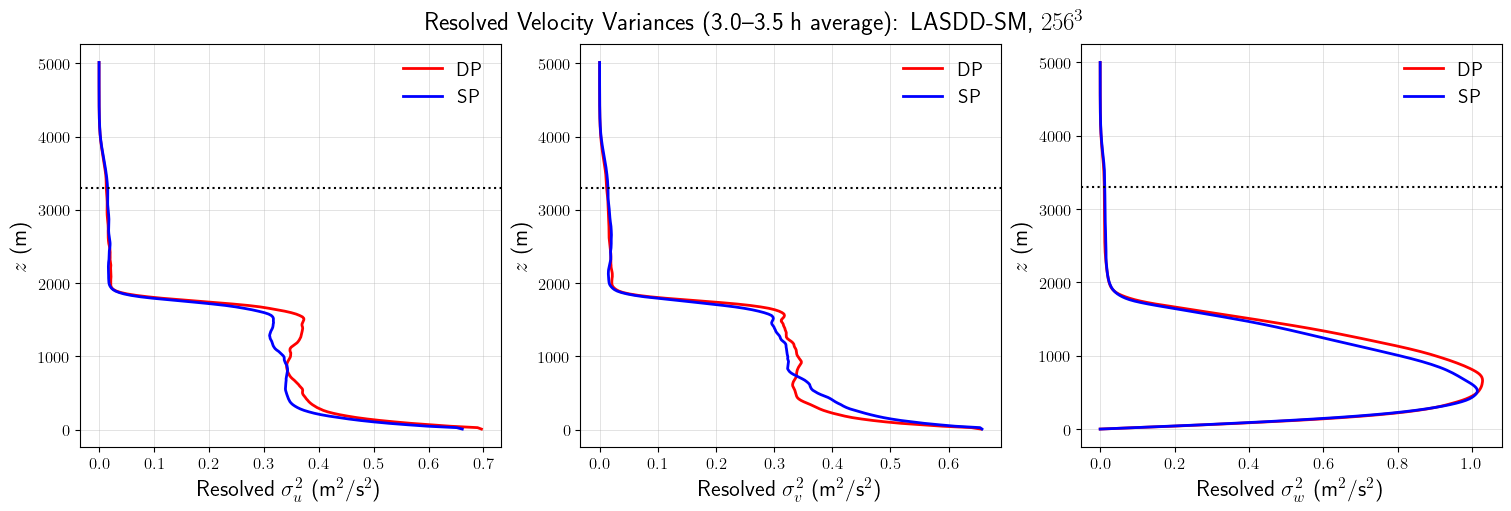

In [83]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(u2_avg_DP, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-r', ax=axs[0], label='DP')
plot_profile(u2_avg_SP, z_1,   xlabel=r"Resolved $\sigma_u^2$ (m$^2$/s$^2$)", linestyle='-b', ax=axs[0], label='SP')

plot_profile(v2_avg_DP, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-r', ax=axs[1], label='DP')
plot_profile(v2_avg_SP, z_1,   xlabel=r"Resolved $\sigma_v^2$ (m$^2$/s$^2$)", linestyle='-b', ax=axs[1], label='SP')

plot_profile(w2_avg_DP, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-r', ax=axs[2], label='DP')
plot_profile(w2_avg_SP, z_w_1, xlabel=r"Resolved $\sigma_w^2$ (m$^2$/s$^2$)", linestyle='-b', ax=axs[2], label='SP')

for ax in axs:
    ax.axhline(y=z_damping, color='k', linestyle=':', linewidth=1.5)
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle(
    f"Resolved Velocity Variances (3.0--3.5 h average): "
    f"{_sgs_label[optSGS]}, {_res_label[optRes]}",
    fontsize=18
)
plt.show()

## Vertical Heat Fluxes

The three panels show resolved, SGS, and total (resolved + SGS) vertical heat flux profiles. Double- and single-precision runs are compared at the selected resolution and SGS model.

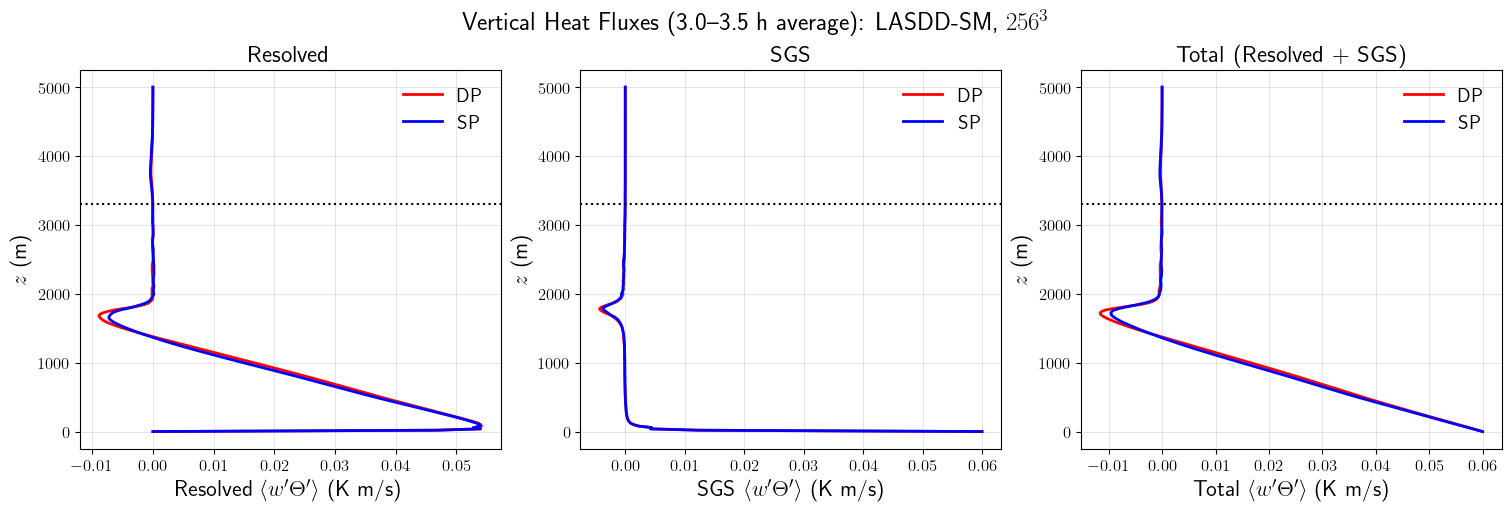

In [84]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_profile(wTH_avg_DP, z_w_1, xlabel=r"Resolved $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-r', label='DP', ax=axs[0])
plot_profile(wTH_avg_SP, z_w_1, xlabel=r"Resolved $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-b', label='SP', ax=axs[0])
axs[0].set_title("Resolved")

plot_profile(qz_avg_DP, z_w_1, xlabel=r"SGS $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-r', label='DP', ax=axs[1])
plot_profile(qz_avg_SP, z_w_1, xlabel=r"SGS $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-b', label='SP', ax=axs[1])
axs[1].set_title("SGS")

plot_profile(wTH_tot_DP, z_w_1, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-r', label='DP', ax=axs[2])
plot_profile(wTH_tot_SP, z_w_1, xlabel=r"Total $\langle w'\Theta' \rangle$ (K m/s)", linestyle='-b', label='SP', ax=axs[2])
axs[2].set_title("Total (Resolved + SGS)")

for ax in axs:
    ax.axhline(y=z_damping, color='k', linestyle=':', linewidth=1.5)
    ax.grid()
    ax.legend(frameon=False)

fig.suptitle(
    f"Vertical Heat Fluxes (3.0--3.5 h average): "
    f"{_sgs_label[optSGS]}, {_res_label[optRes]}",
    fontsize=18
)
plt.show()